# 线性回归 Linear Regression 讲解与实现

这个 notebook 用一个一维线性回归例子说明：

1. 线性回归在学什么
2. 如何用闭式解直接求参数
3. 如何用梯度下降迭代优化参数
4. 如何观察损失下降和拟合效果

为了让代码在最小 Python 环境里也能运行，核心计算只使用标准库。绘图部分会尝试导入 `matplotlib`，如果本机没有安装，可以直接跳过绘图单元。

我们要拟合的模型是：

$$
\hat{y} = wx + b
$$

其中 `w` 是斜率，`b` 是截距。

In [22]:
import random
from statistics import mean

random.seed(7)

## 1. 构造一份带噪声的数据

假设真实关系是：

$$
y = 3x + 2 + \epsilon
$$

其中 `epsilon` 是噪声。实际训练时，模型不知道 `3` 和 `2`，它只能从样本里估计这两个参数。

In [23]:
n_samples = 80
true_w = 3.0
true_b = 2.0

x = [-3 + 6 * i / (n_samples - 1) for i in range(n_samples)]
noise = [random.gauss(0.0, 1.0) for _ in range(n_samples)]
y = [true_w * xi + true_b + eps for xi, eps in zip(x, noise)]

print("样本数量:", len(x))
print("前 5 个样本:")
for i in range(5):
    print(f"x={x[i]: .3f}, y={y[i]: .3f}")

样本数量: 80
前 5 个样本:
x=-3.000, y=-7.256
x=-2.924, y=-6.261
x=-2.848, y=-6.770
x=-2.772, y=-6.632
x=-2.696, y=-7.019


## 2. 损失函数：均方误差 MSE

线性回归最常用的目标是最小化均方误差：

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y_i} - y_i)^2
$$

误差越小，说明预测值 `y_pred` 越接近真实值 `y`。

In [24]:
def predict(x_values, w, b):
    return [w * xi + b for xi in x_values]


def mse_loss(y_pred, y_true):
    squared_errors = [(pred - true) ** 2 for pred, true in zip(y_pred, y_true)]
    return mean(squared_errors)


initial_w = 0.0
initial_b = 0.0
initial_loss = mse_loss(predict(x, initial_w, initial_b), y)
print("initial loss:", round(initial_loss, 4))

initial loss: 31.2134


## 3. 方法一：闭式解

一维线性回归可以直接用下面的公式求最优参数：

$$
w = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

$$
b = \bar{y} - w\bar{x}
$$

这就是普通最小二乘法在一维场景下的闭式解。

In [25]:
x_mean = mean(x)
y_mean = mean(y)

numerator = sum((xi - x_mean) * (yi - y_mean) for xi, yi in zip(x, y))
denominator = sum((xi - x_mean) ** 2 for xi in x)

closed_form_w = numerator / denominator
closed_form_b = y_mean - closed_form_w * x_mean
closed_form_loss = mse_loss(predict(x, closed_form_w, closed_form_b), y)

print("closed form w:", round(closed_form_w, 4))
print("closed form b:", round(closed_form_b, 4))
print("closed form loss:", round(closed_form_loss, 4))

closed form w: 2.9501
closed form b: 1.8883
closed form loss: 0.8779


## 4. 方法二：梯度下降

梯度下降不直接套公式，而是从一个初始参数开始，反复沿着让损失下降的方向更新参数。

对于：

$$
L = \frac{1}{n}\sum (wx_i + b - y_i)^2
$$

两个梯度分别是：

$$
\frac{\partial L}{\partial w} = \frac{2}{n}\sum (\hat{y_i} - y_i)x_i
$$

$$
\frac{\partial L}{\partial b} = \frac{2}{n}\sum (\hat{y_i} - y_i)
$$

In [26]:
w = 0.0
b = 0.0
learning_rate = 0.03
epochs = 300
loss_history = []

for epoch in range(epochs):
    y_pred = predict(x, w, b)
    errors = [pred - true for pred, true in zip(y_pred, y)]
    loss = mse_loss(y_pred, y)
    loss_history.append(loss)

    grad_w = 2 * mean(error * xi for error, xi in zip(errors, x))
    grad_b = 2 * mean(errors)

    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"epoch={epoch:3d}, loss={loss:.4f}, w={w:.4f}, b={b:.4f}")

print("\ntrue w, b:", true_w, true_b)
print("learned w, b:", round(w, 4), round(b, 4))

epoch=  0, loss=31.2134, w=0.5445, b=0.1133
epoch= 50, loss=0.8853, w=2.9500, b=1.8078
epoch=100, loss=0.8780, w=2.9501, b=1.8847
epoch=150, loss=0.8779, w=2.9501, b=1.8881
epoch=200, loss=0.8779, w=2.9501, b=1.8883
epoch=250, loss=0.8779, w=2.9501, b=1.8883
epoch=299, loss=0.8779, w=2.9501, b=1.8883

true w, b: 3.0 2.0
learned w, b: 2.9501 1.8883


## 5. 可选：观察损失下降

如果安装了 `matplotlib`，可以运行下面的单元画出损失曲线。没有安装也不影响前面的核心训练代码。

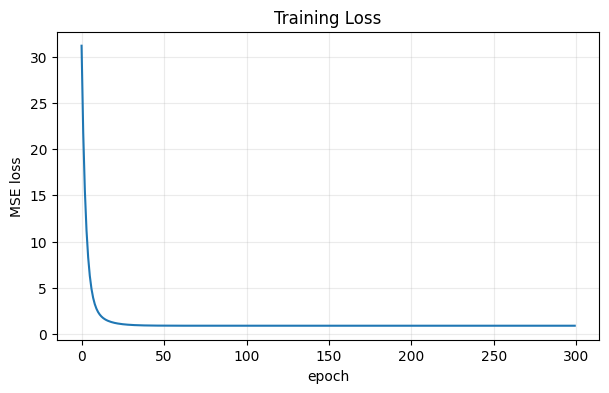

In [27]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.title("Training Loss")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss")
    plt.grid(alpha=0.25)
    plt.show()
except ImportError:
    print("matplotlib 未安装，跳过绘图。最后 5 个 loss:")
    print([round(value, 4) for value in loss_history[-5:]])

## 6. 可选：对比拟合结果

下面把真实样本点、闭式解直线、梯度下降得到的直线画在一起。两条拟合线应该非常接近。

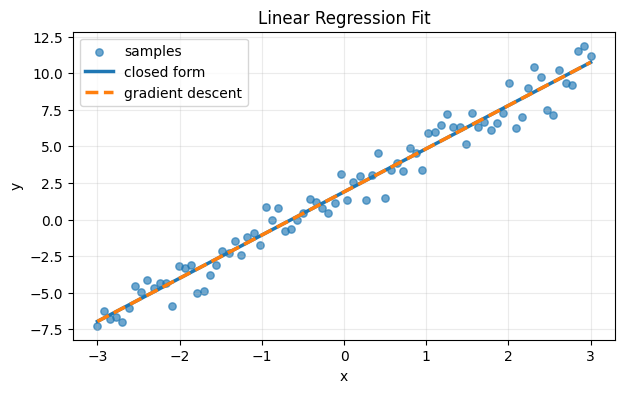

In [28]:
try:
    import matplotlib.pyplot as plt

    y_closed_form = predict(x, closed_form_w, closed_form_b)
    y_gradient_descent = predict(x, w, b)

    plt.figure(figsize=(7, 4))
    plt.scatter(x, y, s=28, alpha=0.65, label="samples")
    plt.plot(x, y_closed_form, linewidth=2.5, label="closed form")
    plt.plot(x, y_gradient_descent, linestyle="--", linewidth=2.5, label="gradient descent")
    plt.title("Linear Regression Fit")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
except ImportError:
    print("matplotlib 未安装，跳过绘图。")
    print("closed form:", round(closed_form_w, 4), round(closed_form_b, 4))
    print("gradient descent:", round(w, 4), round(b, 4))

## 7. 小结

线性回归的核心非常直接：

- 假设目标和特征之间近似满足线性关系
- 用均方误差衡量预测偏差
- 可以用闭式解直接求最优参数
- 也可以用梯度下降一步步逼近最优参数

在更复杂的深度学习模型里，很多训练思想和这里类似：定义模型、定义损失、计算梯度、更新参数。